### datasources

In [122]:
import pandas as pd
import seaborn as sns
%run plotfuncs

In [124]:
dir = './corn_regional_market_share.csv'
marketshare = pd.read_csv(dir)

### EDA - Regional Market Share Data

In [9]:
marketshare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country_name                95 non-null     object 
 1   country_code                95 non-null     object 
 2   region_name                 95 non-null     object 
 3   region_id                   95 non-null     object 
 4   percent_country_production  94 non-null     float64
dtypes: float64(1), object(4)
memory usage: 3.8+ KB


In [10]:
marketshare.head()

,country_name,country_code,region_name,region_id,percent_country_production
0,Argentina,AR,Buenos Aires,bffad37a-7c60-432f-984a-8ea83a944311,27.0
1,Argentina,AR,Córdoba,154a85ea-1f8c-4fb8-b0d4-ba26087d9ee7,35.0
2,Argentina,AR,Santa Fe,8ab0a622-787a-43cb-b13f-95955bf3dfd8,10.0
3,Argentina,AR,Santiago del Estero,50e23c9b-44b4-4bbd-8a94-a722c289bb4a,9.0
4,Argentina,AR,Entre Ríos,db76c31d-17f5-4980-b5fc-038ca13cf164,12.0


In [45]:
df1 = marketshare.groupby('country_name').agg({'country_code':lambda x:x.unique()}).reset_index()
df2 = marketshare.groupby('country_code').agg({'country_name':lambda x:x.unique()}).reset_index()
pd.concat([df1,df2],axis=1)
## country_name and country_code columns are one-to-one

,country_name,country_code,country_code,country_name
0,Argentina,[AR],AR,[Argentina]
1,Brazil,[BR],BR,[Brazil]
2,Canada,[CA],CA,[Canada]
3,China,[CN],CN,[China]
4,European Union,[EU],EU,[European Union]
5,India,[IN],IN,[India]
6,Mexico,[MX],MX,[Mexico]
7,Paraguay,[PY],PY,[Paraguay]
8,Russia,[RU],RU,[Russia]
9,South Africa,[ZA],UA,[Ukraine]


In [32]:
marketshare.groupby('country_name').sum()['percent_country_production']
## there are missing regions, but all within 100 percent

country_name
Argentina          93.00
Brazil            100.00
Canada            100.00
China              64.00
European Union     75.00
India              64.00
Mexico             62.00
Paraguay           91.00
Russia             89.00
South Africa       96.78
Ukraine            47.00
United States      84.86
Name: percent_country_production, dtype: float64

In [46]:
marketshare[marketshare.percent_country_production.isnull()]
## from data documentation: "Some regions may have missing or zero production percentages"

,country_name,country_code,region_name,region_id,percent_country_production
8,Brazil,BR,Espírito Santo,f69dd890-c9c2-4c37-b3e9-4eae47be9bd2,NaN


In [52]:
marketshare['percent_country_production'] = marketshare.percent_country_production.fillna(0.00)
## since all subregions' market shares in Brazil shouldn't exceed one and have been one, the only missing
## market share is deducted to be zero percent

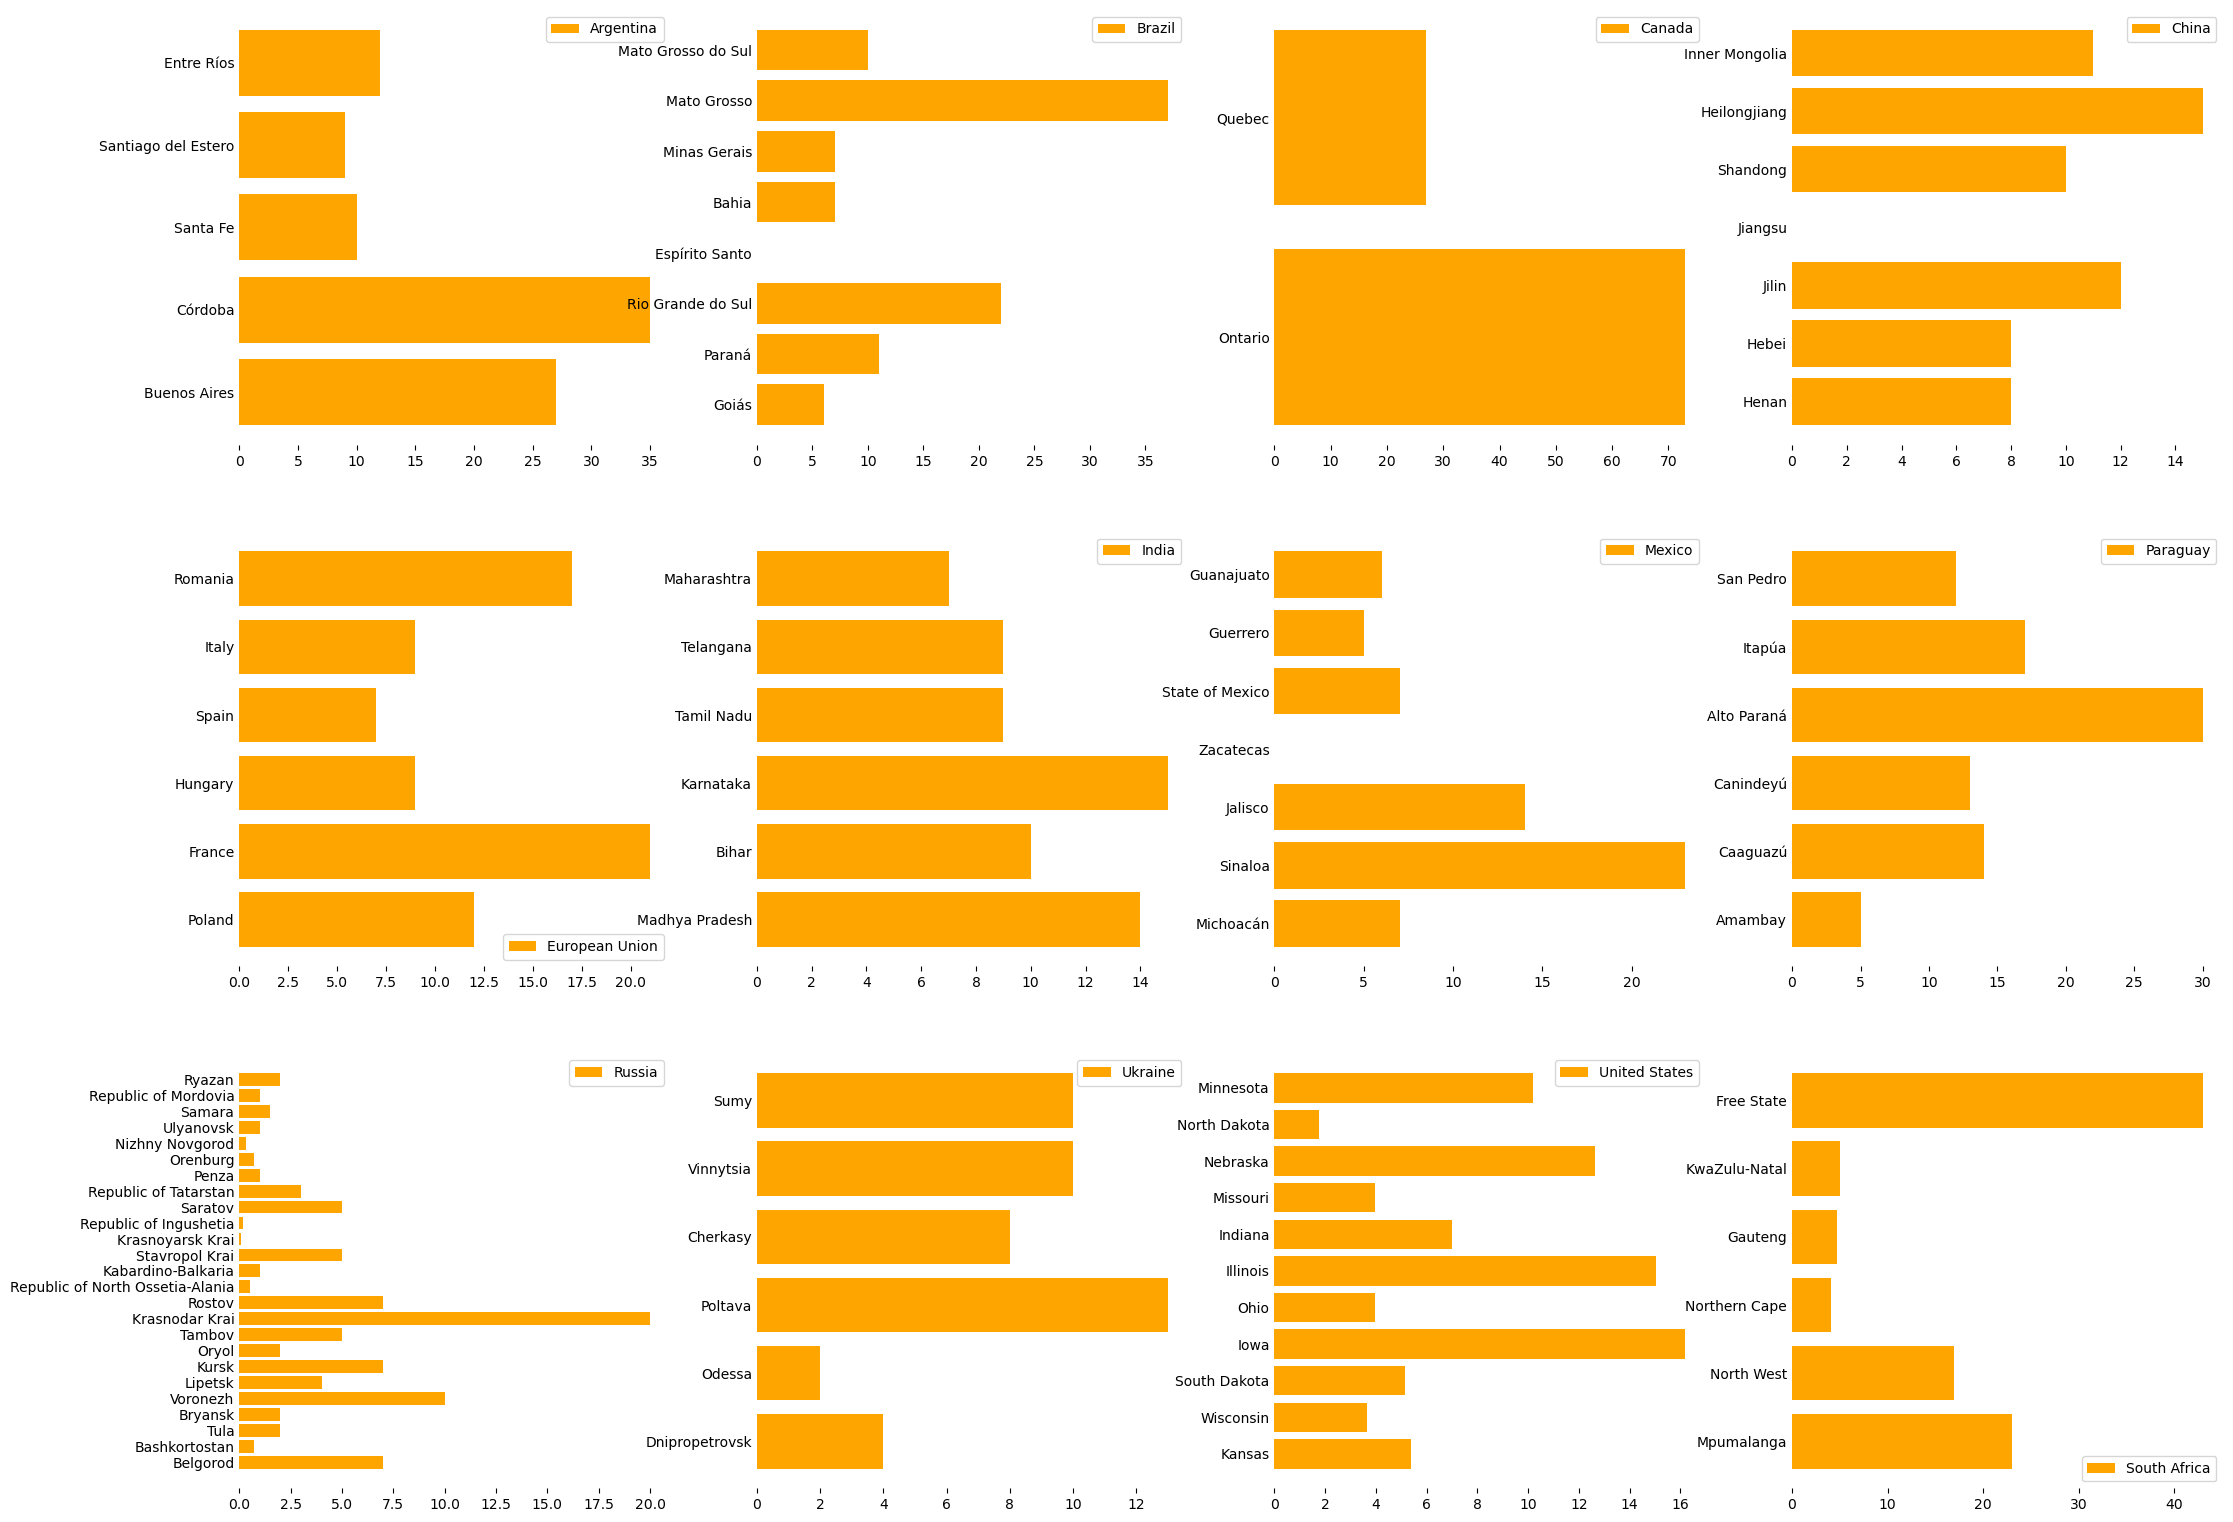

In [123]:
barplots(marketshare,'country_name','percent_country_production','region_name')